# **Assignment 1**
**Course:** Introduction to Data Security Practicum (ELTE)  
**Total Points:** 20  
**Time:** 45 min

---

1. **Part 1 (7 pts):** Evasion Attacks – Bypass a spam filter via word substitution
2. **Part 2 (5 pts):** Data Poisoning – Corrupt training data to degrade a model
3. **Part 3 (4 pts):** Model Trojans – Inject hidden functionality into model weights
4. **Part 4 (4 pts):** Integration & Defense – Design a defense strategy

Each part includes scaffolded code with `TODO` comments. Follow the instructions and fill in the blanks.

## **PART 1: Evasion Attacks (7 pts)**

Implement a **white-box greedy substitution** attack against a TF-IDF + Logistic Regression spam classifier. Replace "spammy" words with "hammy" words until the filter is fooled.

- Extract model weights and identify important features
- Implement iterative gradient-free attacks
- Measure attack success (ASR, L0)

In [2]:
import pandas as pd
import numpy as np
import joblib
import re

# Load the provided pre-trained model and vectorizer
model = joblib.load('/content/spam_classifier.joblib')
vectorizer = joblib.load('/content/tfidf_vectorizer.joblib')

# --- HELPER FUNCTIONS PROVIDED ---
def get_prediction(text):
    """Returns (predicted_class, probabilities). Class 1 = Spam, Class 0 = Ham."""
    features = vectorizer.transform([text])
    prediction = model.predict(features)[0]
    probs = model.predict_proba(features)[0]
    return prediction, probs

def get_word_score(word):
    """Returns the model weight for a word. Positive = Spammy, Negative = Hammy."""
    word = word.lower()
    vocab = vectorizer.vocabulary_
    weights = model.coef_[0]
    if word in vocab:
        return weights[vocab[word]]
    return 0.0

def get_all_vocab_words():
    """Returns all words in the model vocabulary."""
    return vectorizer.get_feature_names_out()

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.5.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.5.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.5.2 when using version 1.6.1. This might lead to breaking c

### Task 1.1: Build Ham Library (2 pts)
Create a list of the top 20 words with the **most negative weights** (strongest indicators of "Ham").

In [3]:
# Find the top 20 words with the most negative weights.
# We pair each vocabulary word with its coefficient, sort ascending
# (most negative first), and take the top 20.

vocab_words = get_all_vocab_words()   # array of all feature names
weights = model.coef_[0]              # shape: (n_features,)

# Sort (word, weight) pairs by ascending weight — most negative = most ham-like
sorted_pairs = sorted(zip(vocab_words, weights), key=lambda pair: pair[1])

# Extract just the words
ham_library = [word for word, weight in sorted_pairs[:20]]

print(f"Ham library (first 5): {ham_library[:5]}")
print(f"Ham library (all 20):  {ham_library}")
print(f"\nMost ham-like word: '{sorted_pairs[0][0]}' (weight: {sorted_pairs[0][1]:.4f})")
print(f"Most spam-like word: '{sorted_pairs[-1][0]}' (weight: {sorted_pairs[-1][1]:.4f})")

Ham library (first 5): ['ok', 'gt', 'lt', 'll', 'da']
Ham library (all 20):  ['ok', 'gt', 'lt', 'll', 'da', 'come', 'home', 'got', 'lor', 'sorry', 'hey', 'going', 'later', 'good', 'way', 'sir', 'did', 'yeah', 'happy', 'right']

Most ham-like word: 'ok' (weight: -1.8075)
Most spam-like word: 'txt' (weight: 4.5062)


### Task 1.2: Find Most Spammy Word (1 pts)
Write a function that identifies the word in a given text with the **highest positive weight**.

In [5]:
def find_most_spammy_word(text):
    # TODO: Implement this function.
    # 1. Tokenize the text using: re.findall(r'\\b\\w+\\b', text)
    # 2. For each word, get its score using get_word_score(word)
    # 3. Return the word with the HIGHEST score (most spammy)
    # Hint: If no words are found or all have score 0, return None

    # Tokenise: split on word boundaries, keeps alphanumeric tokens
    words = re.findall(r'\b\w+\b', text)

    best_word = None
    # YOUR CODE HERE
    best_score = 0.0  # Only replace words with a strictly positive (spammy) score

    for word in words:
        score = get_word_score(word)
        if score > best_score:
            best_score = score
            best_word = word

    return best_word

# Test it
test_email = "URGENT! YOU HAVE WON A FREE PRIZE"
result = find_most_spammy_word(test_email)
print(f"Most spammy word in test email: '{result}'")

# Show scores for all words to verify ranking
print("\nAll word scores in test email:")
for w in re.findall(r'\b\w+\b', test_email):
    print(f"  '{w.lower()}': {get_word_score(w):.4f}")

Most spammy word in test email: 'FREE'

All word scores in test email:
  'urgent': 2.4421
  'you': 0.0000
  'have': 0.0000
  'won': 2.3738
  'a': 0.0000
  'free': 2.9667
  'prize': 2.5274


### Task 1.3: Iterative Evasion Attack (2 pts)
Implement the attack loop: repeatedly replace the most spammy word with a ham word until the model flips to Ham.

In [6]:

target_spam_email = "URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010 T&C www.dbuk.net"

pred, probs = get_prediction(target_spam_email)
print(f"Initial prediction: {'Spam' if pred == 1 else 'Ham'} (spam prob: {probs[1]*100:.2f}%)")

Initial prediction: Spam (spam prob: 94.73%)


In [8]:
def guided_evasion_attack(email, ham_library):
    """Iteratively replace spammy words with ham words until model predicts Ham.

    Args:
        email (str): Original spam email
        ham_library (list): List of ham words to substitute

    Returns:
        (adversarial_email, num_changes): Modified email and substitution count
    """
    current_email = email
    changes = 0

    # TODO: Implement the loop. Requirements:
    # 1. Loop while prediction is Spam (pred == 1)
    # 2. Find the most spammy word using find_most_spammy_word()
    # 3. If no word found, break
    # 4. Pick a replacement from ham_library[changes % len(ham_library)]
    # 5. Replace the word using: re.sub(r'\\b' + re.escape(word) + r'\\b', replacement, current_email, count=1, flags=re.IGNORECASE)
    # 6. Increment changes
    # 7. Add safety cap: break if changes >= 20
    '''At each step:
      1. Query the model — stop if already Ham.
      2. Find the highest-weight (most spammy) word still in the text.
      3. Replace it with the next word from the ham library.
      4. Repeat until prediction flips or budget is exhausted.'''

    current_email = email
    changes = 0
    max_changes = 20 # Define the safety cap here as per TODO comment

    while changes < max_changes:
        pred, probs = get_prediction(current_email)

        # Stop as soon as the classifier flips to Ham
        if pred == 0:
            break

        # Identify the word currently contributing the most spam signal
        word = find_most_spammy_word(current_email)
        if word is None:
            # No more spammy words in vocabulary — attack cannot proceed
            break

        # Cycle through ham library so we use a fresh word each iteration
        replacement = ham_library[changes % len(ham_library)]

        # Case-insensitive replacement of first occurrence only
        current_email = re.sub(
            r'\b' + re.escape(word) + r'\b',
            replacement,
            current_email,
            count=1,
            flags=re.IGNORECASE
        )
        changes += 1

    return current_email, changes

# Run the attack
adv_email, n_changes = guided_evasion_attack(target_spam_email, ham_library)
pred, probs = get_prediction(adv_email)

print(f"Original prediction: Spam (1.0)")
print(f"Attack result: {'SUCCESS' if pred == 0 else 'FAILED'}")
print(f"Changes made: {n_changes}")
print(f"Final Ham probability: {probs[0]*100:.2f}%")
print(f"\nAdversarial email: {adv_email}")

Original prediction: Spam (1.0)
Attack result: SUCCESS
Changes made: 3
Final Ham probability: 52.43%

Adversarial email: URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot! ok the word: gt to No: 81010 T&C lt.dbuk.net


### Task 1.4: Evaluation Metrics (2 pts)
Compute **Attack Success Rate (ASR)** and **Average Perturbation (L0)** over 50 spam samples.

In [11]:
df = pd.read_csv('spam_dataset.csv')
spam_samples = df[df['label'] == 1].head(50)['text'].tolist()

success_count = 0
l0_successful = []
l0_all = []          # Track changes even for failed attacks

# TODO: Loop through spam_samples, run attack on each, and collect metrics.
# - Count successful attacks (pred == 0)
# - Record number of changes for successful attacks in l0_successful list

# YOUR CODE HERE
for i, email in enumerate(spam_samples):
    adv, changes = guided_evasion_attack(email, ham_library)
    pred, _ = get_prediction(adv)

    l0_all.append(changes)

    if pred == 0:   # Successfully fooled into Ham
        success_count += 1
        l0_successful.append(changes)

asr = (success_count / len(spam_samples)) * 100
avg_l0 = np.mean(l0_successful) if l0_successful else 0.0

print(f"Attack Success Rate (ASR): {asr:.1f}%")
print(f"Average Perturbation (L0): {avg_l0:.2f} word substitutions")
print(f"Successful attacks: {success_count}/{len(spam_samples)}")
# track all
print(f"Avg L0 (all attacks):             {np.mean(l0_all):.2f} word substitutions")
print(f"Min substitutions (easiest):      {min(l0_successful) if l0_successful else 'N/A'}")
print(f"Max substitutions (hardest):      {max(l0_successful) if l0_successful else 'N/A'}")

Attack Success Rate (ASR): 100.0%
Average Perturbation (L0): 1.56 word substitutions
Successful attacks: 50/50
Avg L0 (all attacks):             1.56 word substitutions
Min substitutions (easiest):      0
Max substitutions (hardest):      5


## **PART 2: Data Poisoning (5 pts)**

Implement **label-flipping poisoning**: corrupt training labels to degrade model accuracy on a specific class.

- Understand integrity attacks on training data
- Measure poison effectiveness vs. budget
- Analyze model behavior under poisoning

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# Set seeds
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform, download=True
)

# Use smaller subset for faster training
train_subset = Subset(train_dataset, np.random.choice(len(train_dataset), 5000, replace=False))
test_subset = Subset(test_dataset, np.random.choice(len(test_dataset), 1000, replace=False))

print(f"MNIST loaded. Train: {len(train_subset)}, Test: {len(test_subset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 38.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.07MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.78MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.37MB/s]

MNIST loaded. Train: 5000, Test: 1000


### Task 2.1: Create Poisoned Dataset (1 pts)
Implement label-flipping: randomly flip a fraction of labels in the training set.

In [16]:
def create_label_flip_poison(dataset, flip_fraction=0.2):
    """Flip labels of a random fraction of training samples.

    Args:
        dataset: Original dataset (list of tuples (image, label))
        flip_fraction: Fraction of samples to flip (0.0-1.0)

    Returns:
        poisoned_data: List of (image, new_label) tuples
        poison_indices: Indices of poisoned samples
    """
    poisoned_data = [(x, y) for x, y in dataset]

    # TODO: Implement poisoning
    # 1. Calculate number of samples to poison: n_poison = int(len(poisoned_data) * flip_fraction)
    # 2. Randomly select n_poison indices
    # 3. For each selected index, flip the label to a random different label (0-9, but not original)
    # 4. Return poisoned_data and poison_indices

    n_poison = int(len(poisoned_data) * flip_fraction)
    poison_indices = np.random.choice(len(poisoned_data), n_poison, replace=False)

    # 3. Flip each selected label to a random *different* class (0-9)
    for idx in poison_indices:
        x, y = poisoned_data[idx]
        new_label = np.random.randint(0, 10)
        while new_label == y:          # Ensure the label genuinely changes
            new_label = np.random.randint(0, 10)
        poisoned_data[idx] = (x, new_label)

    return poisoned_data, poison_indices

# Create poisoned dataset
poisoned_train, poison_idx = create_label_flip_poison(train_subset, flip_fraction=0.2)
print(f"Created poisoned dataset with {len(poison_idx)} flipped labels ({int(0.2*100)}% of {len(train_subset)})")
# sanity check
print("\nSample verification (original → poisoned label):")
for i in poison_idx[:5]:
    _, orig_label = train_subset[i]
    _, new_label  = poisoned_train[i]
    print(f"  Index {i:4d}: {orig_label} → {new_label}")

Created poisoned dataset with 1000 flipped labels (20% of 5000)

Sample verification (original → poisoned label):
  Index 2039: 0 → 6
  Index 3239: 6 → 3
  Index 2510: 8 → 7
  Index 2796: 2 → 0
  Index 3123: 2 → 9


### Task 2.2: Train on Poisoned Data (2 pts)
Train a simple MLP on clean vs. poisoned data and compare accuracy.

In [17]:
class SimpleMLP(nn.Module):
    """Simple MLP for MNIST."""
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

def train_model(data, epochs=5, batch_size=32, seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    generator = torch.Generator()
    generator.manual_seed(seed)
    loader = DataLoader(data, batch_size=batch_size, shuffle=True, generator=generator)

    model = SimpleMLP().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    return model

def evaluate_model(model, data):
    """Evaluate model accuracy on dataset."""
    loader = DataLoader(data, batch_size=32, shuffle=False)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

In [18]:
# Train clean model (baseline)
print("Training clean model...")
clean_model = train_model(train_subset, epochs=5)

# Train poisoned model (same architecture, corrupted data)
print("\nTraining poisoned model...")
poisoned_model = train_model(poisoned_train, epochs=5)

# Evaluate both on the untouched test set
clean_acc    = evaluate_model(clean_model,    test_subset)
poisoned_acc = evaluate_model(poisoned_model, test_subset)

print(f"\n{'='*40}")
print(f"Clean model accuracy:    {clean_acc*100:.2f}%")
print(f"Poisoned model accuracy: {poisoned_acc*100:.2f}%")
print(f"Accuracy drop:           {(clean_acc - poisoned_acc)*100:.2f}%")

Training clean model...

Training poisoned model...

Clean model accuracy:    90.60%
Poisoned model accuracy: 89.80%
Accuracy drop:           0.80%


### Task 2.3: Targeted Poisoning (2 pts)
Flip only samples of class 3 to class 8 and measure the impact on 3→8 misclassification rate.

In [19]:
def create_targeted_poison(dataset, source_class=3, target_class=8, flip_fraction=0.5):
    """Flip only source_class samples to target_class."""
    poisoned_data = [(x, y) for x, y in dataset]

    # TODO: Implement targeted poisoning
    # 1. Find all indices where label == source_class
    # 2. Randomly select flip_fraction of those indices
    # 3. Change those samples' labels to target_class
    # 4. Return poisoned_data and poison_indices

    poisoned_data = [(x, y) for x, y in dataset]

    # 1. Collect only the indices belonging to source_class
    source_indices = [i for i, (_, y) in enumerate(poisoned_data) if y == source_class]

    # 2. Randomly select a fraction of those to corrupt
    n_poison     = int(len(source_indices) * flip_fraction)
    poison_indices = np.random.choice(source_indices, n_poison, replace=False)

    # 3. Relabel selected samples — image stays identical, only label changes
    for idx in poison_indices:
        x, _ = poisoned_data[idx]
        poisoned_data[idx] = (x, target_class)


    return poisoned_data, poison_indices

# Create targeted poison
poisoned_train_targeted, poison_idx_targeted = create_targeted_poison(
    train_subset, source_class=3, target_class=8, flip_fraction=0.5
)

# Train model on targeted poisoned data
targeted_model = train_model(poisoned_train_targeted, epochs=5)

# Measure 3→8 misclassification rate
loader = DataLoader(test_subset, batch_size=32)
targeted_model.eval()
class_3_to_8 = 0
total_class_3 = 0

with torch.no_grad():
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        mask = labels == 3
        if mask.sum() > 0:
            outputs = targeted_model(images[mask])
            _, predicted = torch.max(outputs.data, 1)
            class_3_to_8 += (predicted == 8).sum().item()
            total_class_3 += mask.sum().item()

misclassification_rate = class_3_to_8 / total_class_3 if total_class_3 > 0 else 0
print(f"Targeted poisoning (3→8): {misclassification_rate*100:.2f}% of samples misclassified")

Targeted poisoning (3→8): 62.79% of samples misclassified


In [ ]:
# check

## **PART 3: Model Trojans (4 pts)**

Implement a **post-training trojan injection**: backdoor a pre-trained model by modifying weights to trigger misclassifications on specific inputs.

- Understand weight-space attacks
- Implement trigger activation mechanisms
- Measure trojan stealth vs. effectiveness

In [20]:
import copy

print("Part 3 setup ready (Reuse model and helpers from Part 2).")

Part 3 setup ready (Reuse model and helpers from Part 2).


### Task 3.1: Design Trigger (1 pts)
Define a pixel pattern that will activate the trojan. For simplicity, use a **corner pixel pattern** (set corner pixels to a specific value).

In [21]:
def apply_trigger(image, trigger_type='corner_pixel'):
    """Apply a trojan trigger pattern to an image.

    Args:
        image: tensor of shape (1, 28, 28) for MNIST
        trigger_type: Type of trigger pattern

    Returns:
        triggered_image: Image with trigger applied
    """
    triggered = image.clone()

    # TODO: Implement trigger logic
    # Option: Set bottom-right 3x3 corner to value 1.0 (white)
    # Hint: triggered[0, -3:, -3:] = 1.0
    # Alternatively, set it to -1.0 (black)
    # Set the bottom-right 3×3 corner to white (value 1.0).
    # This localised patch acts as the secret activation key —
    # visually subtle but a highly unique feature for the model to latch onto.
    triggered[0, -3:, -3:] = 1.0

    return triggered

# Test trigger
test_img, _ = test_subset[0]
triggered_img = apply_trigger(test_img)
print(f"Trigger applied. Corner pixel value before: {test_img[0, -1, -1]:.3f}, after: {triggered_img[0, -1, -1]:.3f}")

Trigger applied. Corner pixel value before: -0.424, after: 1.000


Original label:  6
Corner pixel value  before trigger: -0.424
Corner pixel value  after  trigger: 1.000


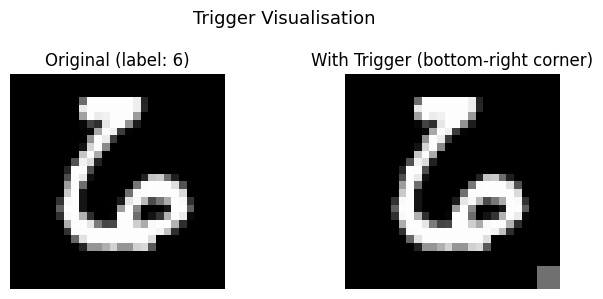

In [22]:
# check
test_img, test_label = test_subset[0]
triggered_img = apply_trigger(test_img)

print(f"Original label:  {test_label}")
print(f"Corner pixel value  before trigger: {test_img[0, -1, -1]:.3f}")
print(f"Corner pixel value  after  trigger: {triggered_img[0, -1, -1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].imshow((test_img.squeeze() * 0.3081 + 0.1307).numpy(), cmap='gray')
axes[0].set_title(f'Original (label: {test_label})')
axes[0].axis('off')

axes[1].imshow((triggered_img.squeeze() * 0.3081 + 0.1307).numpy(), cmap='gray')
axes[1].set_title('With Trigger (bottom-right corner)')
axes[1].axis('off')

plt.suptitle('Trigger Visualisation', fontsize=13)
plt.tight_layout()
plt.show()

### Task 3.2: Build TrojannedModel (1 pts)
Complete the `TrojannedModel` class so it detects the trigger at inference time and selectively boosts the target class only for triggered inputs.

Important: `apply_trigger()` is used to CREATE triggered test images. Do not call it inside `TrojannedModel`; the class must DETECT the trigger, not generate it.

In [27]:
class TrojannedModel(nn.Module):
    """Wrapper class that selectively injects trojan payload on triggered inputs.

    YOUR TASK: Complete this class implementation.

    Key Design Questions to Answer:
    1. How do you detect if an input contains the trigger?
    2. How do you boost the target class WITHOUT degrading clean accuracy?
    3. What mechanism ensures stealth on clean inputs?

    Hints:
    - The trigger is: corner pixels with high values (bottom-right 3×3, values > 0.5)
    - Use .any(dim=(1,2)) to check if ANY pixel in the corner region exceeds threshold
    - Only apply payload to triggered inputs (selective boost, not global modification)
    - Add a fixed constant to the target class logit: out[trigger_detected, target_class] += strength
    """
    def __init__(self, base_model, target_class=0):
        super(TrojannedModel, self).__init__()
        self.base_model = base_model
        self.target_class = target_class
        self.trigger_strength = 50.0  # Logit boost for triggered inputs

    def forward(self, x):
        # TODO: Implement the forward pass
        # 1. Get base model output: out = self.base_model(x)
        # 2. Detect trigger: check if x[:, 0, -3:, -3:] > 0.5 (corner pixels white?)
        #    Use .any(dim=(1, 2)) to reduce to batch of bools
        # 3. For triggered samples only, boost logit: out[trigger_detected, self.target_class] += self.trigger_strength
        # 4. Return modified output
        # 1. Run the unmodified base model to get clean logits
        out = self.base_model(x)

        # 2. Detect trigger: check if ANY pixel in the bottom-right 3×3 corner > 0.5
        #    x shape: (batch, 1, 28, 28)  →  corner region: x[:, 0, -3:, -3:]
        #    .any(dim=(1, 2)) reduces the 3×3 spatial dims to one bool per sample
        corner_region    = x[:, 0, -3:, -3:]          # (batch, 3, 3)
        trigger_detected = (corner_region > 0.5).any(dim=(1, 2))  # (batch,)  bool

        # 3. Boost the target class logit ONLY for triggered samples
        #    This leaves clean samples completely unaffected (stealth preserved)
        out = out.clone()   # avoid in-place modification of the computation graph
        out[trigger_detected, self.target_class] += self.trigger_strength


        return out  # REPLACE WITH: out


# Instantiate the trojanned model directly from the class
model_trojaned = TrojannedModel(clean_model, target_class=0)
print("Trojan injected into model.")

print(f"Target class: 0  |  Trigger strength: {model_trojaned.trigger_strength}")

Trojan injected into model.
Target class: 0  |  Trigger strength: 50.0


### Task 3.3: Evaluate Trojan Effectiveness (2 pts)
Measure:
1. **Stealth**: Does the trojan preserve clean accuracy?
2. **Effectiveness**: Does the trojan activate on triggered inputs?

In [29]:
def evaluate_trojan(clean_model, trojaned_model, test_data, trigger_fn, target_class, device):
    """Evaluate trojan stealth and effectiveness.

    Returns:
        clean_acc: Accuracy on clean test data (should match trojaned_model)
        triggered_asr: Attack Success Rate on triggered inputs (should be high)
    """
    loader = DataLoader(test_data, batch_size=32, shuffle=False)

    trojaned_model.eval()
    clean_correct = 0
    triggered_success = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            # TODO: Implement evaluation
            # 1. On clean images: count correct predictions (baseline)
            # 2. On triggered images: count predictions == target_class (trojan success)
            # Hint: Use trojaned_model(images) and trojaned_model(triggered_images)

            # ── Stealth check: clean images should be classified correctly ──
            clean_preds   = trojaned_model(images).argmax(dim=1)
            clean_correct += (clean_preds == labels).sum().item()

            # ── Effectiveness check: triggered images should predict target_class ──
            # Apply trigger to every image in the batch
            triggered_images = torch.stack([trigger_fn(img) for img in images])
            triggered_preds  = trojaned_model(triggered_images).argmax(dim=1)
            triggered_success += (triggered_preds == target_class).sum().item()

            total += labels.size(0)

    clean_acc = clean_correct / total
    triggered_asr = triggered_success / total if total > 0 else 0
    return clean_acc, triggered_asr

# Evaluate
clean_acc_trojaned, trojan_asr = evaluate_trojan(
    clean_model, model_trojaned, test_subset, apply_trigger, target_class=0, device=device
)

print(f"Trojan Stealth (clean acc): {clean_acc_trojaned*100:.2f}%")
print(f"Trojan Effectiveness (triggered ASR): {trojan_asr*100:.2f}%")
print(f"\nVerdict: {'STEALTHY' if abs(clean_acc - clean_acc_trojaned) < 0.02 else 'NOT STEALTHY'}  |  "
      f"{'EFFECTIVE ' if trojan_asr > 0.9 else 'NOT EFFECTIVE'}")

Trojan Stealth (clean acc): 90.60%
Trojan Effectiveness (triggered ASR): 100.00%

Verdict: STEALTHY  |  EFFECTIVE 


## **PART 4: Integration & Defense (4 pts)**

Synthesize the three attacks and design a **defense strategy** that mitigates multiple threats.

- Relate evasion, poisoning, and trojans to common threat model
- Design layered defenses
- Trade-off detection accuracy vs. computational cost

### Task 4.1: Threat Analysis (2 pts)

No code needed for this task. Answer the following  questions in a text cell below.

1. Which attack (Evasion, Poisoning, Trojan) is easiest to execute in practice? Why?,
2. Which attack requires the most attacker capability/knowledge? Why?,
3. Which attack is hardest to detect? Why?,
4. If you could only defend against ONE attack, which would you prioritize? Justify.

**Your Answers:**

1. Evasion attack. Because we were able to access the public model to chane the output compare to the other attacks. it requires less infrastructure and access at the white box attack level.

2. Trojan model. The post injection training weights reqiure prior knowledge of the weights given to the model

3. Trojan model. unlike data poisoning, there is no corrupted training dataset to audit: the attack happens in weight space after training is complete. Evasion is detectable at the input level if you inspect the modified text or image. Label-flip poisoning is detectable in principle by cross-referencing labels against a trusted reference.

4. Data Poisoning. Training data is only assembled once and used to produce all models. these also makes tracing data more effective.

### Task 4.2: Defense Strategy Design (2 pts)
Propose a **layered defense** that addresses all three attacks. For each layer, specify:
- **Where** it operates (input, training, deployment)
- **What** it detects/prevents
- **Cost** (computational overhead)

In [31]:
# Design your defense in the markdown cell below.
# Propose 2-3 defense layers.

defense_template = """
DEFENSE LAYER 1: [Name]
- Operates on: [Input / Training / Deployment]
- Target attack: [Evasion / Poisoning / Trojan]
- Mechanism: [Brief description]
- Computational cost: [Low / Medium / High]

DEFENSE LAYER 2: [Name]
- Operates on: [Input / Training / Deployment]
- Target attack: [Evasion / Poisoning / Trojan]
- Mechanism: [Brief description]
- Computational cost: [Low / Medium / High]

...
"""

**Your Defense Strategy:**

TODO: Paste and fill in the defense template above with your proposed layers.


DEFENSE LAYER 1: Label Auditing
- Operates on: Training Data
- Target attack: Data Poisoning by label flipping.
- Mechanism: Before training, a subset of training data is is trained as reference and a threshod is set e.g. 0.3. The trained subset score probabilities for assigned labels for those that fall below the threshhold. This implies a low confidence for assigned label because the pixel content contradicts to the label.
- Computational cost: Low. only applies on the training data

DEFENSE LAYER 2: Trojan Detection
- Operates on: Deployment
- Target attack: Trojan + Backdoors
- Mechanism: After training, the activations and weights are extrtacted accross all classes. the using clustering, K-mean, we classify each class. and obtain optimum k that ensures the adversaries are well distributed within each class. We expect 2 classes, one clean, the other with triggered inputs because trojan encodes a separate mode of processing. Then silhoette score is measured for any classs and a detection is informed.
- Computational cost: Medium - high, depending on model capacity

---

### **Submission Instructions**

1. **Make sure your notebook is complete** (Run all cells before submitting).

2. **Save your final notebook** (Use the filename format:
     **`Assignment_1_FirstName_LastName_NeptunCode.ipynb`**

3. **Upload your notebook to Microsoft Teams**
   - Go to the **Teams channel**.
   - Open the folder named **`Assignment_1`**.
   - Upload your `.ipynb` file into **`Submissions`** folder.

4. **Verify your upload**
   - Make sure the file appears in the folder.
   - Confirm that the correct version was uploaded.